In [23]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random

In [24]:
load_dotenv()

True

In [41]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-70B-Instruct",
    task="conversational",
    max_new_tokens=100,
    temperature=0.1,
)
chat_model = ChatHuggingFace(llm=llm)

In [42]:
result = chat_model.invoke("what is capital city of nepal?").content
print(result)

The capital city of Nepal is Kathmandu.


In [43]:
search_tool = DuckDuckGoSearchRun(region = 'us-en')

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """Perform basic arithmetic operations.
    supported operations: add, subtract, multiply, divide
    Args:
        first_num (float): The first number.
        second_num (float): The second number.
        operation (str): The operation to perform. Supported operations: add, subtract, multiply, divide.
        Returns:
            dict: A dictionary containing the result or an error message.
    """
    try:
        if operation == "add":
            return {"result": first_num + second_num}
        elif operation == "subtract":
            return {"result": first_num - second_num}
        elif operation == "multiply":
            return {"result": first_num * second_num}
        elif operation == "divide":
            if second_num != 0:
                return {"result": first_num / second_num}
            else:
                return {"error": "Cannot divide by zero"}
        else:
            return {"error": "Invalid operation"}
    except Exception as e:
        return {"error": str(e)}
    
@tool
def get_stock_price(symbol: str) -> dict:
    """"Fetch the current stock price for a given symbol using the Alpha Vantage API.
    Args:
        symbol (str): The stock symbol to fetch the price for.
    Returns:
        dict: A dictionary containing the stock price or an error message.
    """
    ALPHA_VANTAGE_API_KEY = "3QZR8BL9SAEETTZ7"
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={ALPHA_VANTAGE_API_KEY}"
    r = requests.get(url)
    return r.json()

In [44]:
tools = [search_tool, calculator, get_stock_price]

model_with_tools = chat_model.bind_tools(tools)

In [45]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [46]:
def chat_node(state: ChatState):
    user_input = state["messages"]
    response = model_with_tools.invoke(user_input)
    return {'messages': [response]}

tool_node = ToolNode(tools)# Executes tool call

In [47]:
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)


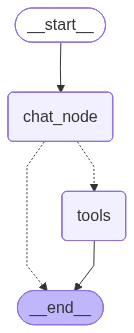

In [48]:
chatbot = graph.compile()

chatbot

In [49]:
final_state = chatbot.invoke({'messages': [HumanMessage(content="What is the capital city of Nepal?")]})

print(final_state['messages'][-1].content)

Kathmandu served as the royal capital of the Kingdom of Nepal and is home to numerous palaces, temples, and gardens reflecting its rich heritage. Since 1985, it has hosted the headquarters of the South Asian Association for Regional Cooperation (SAARC). The capital, Kathmandu, nicknamed the "City of temples", is the largest city in the country and the cultural and economic heart. Other large cities in Nepal include Pokhara, Biratnagar, Lalitpur, Bharatpur, Birgunj, Dharan, Hetauda and Nepalgunj. Swayambhunath Kathmandu Durbar Square Swayambhunath Brief Introduction of Kathmandu Metropolitan City Kathmandu is the capital and eldest metropolitan city of Nepal. The city is the urban core of the Kathmandu Valley in the Himalayas. view more Apr 25, 2017 · Located in the bowl-shaped Kathmandu Valley of central Nepal, Kathmandu is the biggest and capital city of Nepal. Kathmandu is the urban core of the Kathmandu Valley in the Himalayas, which also contains two sister cities, Patan and Bhakta

In [51]:
final_state1 = chatbot.invoke({'messages': [HumanMessage(content="Hello")]})

print(final_state1['messages'][-1].content)

I'm not able to execute a function to provide a specific answer, as no clear question has been asked. If you'd like to ask something or request information on a particular topic, I'd be happy to try and assist you.


In [52]:
final_state3 = chatbot.invoke({'messages': [HumanMessage(content="What is 36*45")]})

print(final_state3['messages'][-1].content)

{"result": 1620.0}


In [53]:
final_state4 = chatbot.invoke({'messages': [HumanMessage(content="What is the stock price of apple?")]})

print(final_state4['messages'][-1].content)

{"Global Quote": {"01. symbol": "AAPL", "02. open": "298.1100", "03. high": "300.5700", "04. low": "295.6200", "05. price": "298.0100", "06. volume": "85962201", "07. latest trading day": "2026-06-18", "08. previous close": "295.9500", "09. change": "2.0600", "10. change percent": "0.6961%"}}
